# Visualization of molecular dynamics

This notebook is a continuation on the SpookyNet MD notebook, running the same type of NVT molecular dynamics simulation but with two differences: a different ML potential and a focus on trajectory visualization rather than structural analysis. Where the previous notebook used SpookyNet and analyzed bond lengths, angles, and species classification in detail, this one uses MACE and demonstrates how to convert a trajectory into an animated GIF directly viewable in the notebook.

The system is a Pt(111) slab with 32 explicit water molecules, a pure water overlayer rather than the mixed OH-H₂O layer from the previous notebook. All Pt atoms are frozen so only the water dynamics are computed, which is a reasonable approximation when the focus is on the liquid-solid interface rather than surface reconstruction. The simulation runs at 300 K with a 0.5 fs timestep, the smaller timestep chosen to accurately resolve the high-frequency O-H stretching vibrations around 3500 cm⁻¹. The thermostat is NVT Berendsen with a 500 fs coupling constant for gentle temperature control during the short equilibration.


In [1]:
%%capture
!pip install mace-torch ase

In [2]:
##-Visualization and file handling
import os
import imageio
from PIL import Image
from IPython.display import Image as IPImage

##-ASE
from ase import units
from ase.constraints import FixAtoms
from ase.io import read, write
from ase.io.trajectory import Trajectory
from ase.visualize import view
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

##-MACE
from mace.calculators import MACECalculator

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [3]:
!wget https://raw.githubusercontent.com/vilab-tartu/test_models/refs/heads/main/Pt-w/Pt-32H2O_MD.xyz

--2026-06-22 14:23:51--  https://raw.githubusercontent.com/vilab-tartu/test_models/refs/heads/main/Pt-w/Pt-32H2O_MD.xyz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24239 (24K) [text/plain]
Saving to: ‘Pt-32H2O_MD.xyz’

Pt-32H2O_MD.xyz     100%[===================>]  23.67K  --.-KB/s    in 0.001s  

2026-06-22 14:23:51 (25.6 MB/s) - ‘Pt-32H2O_MD.xyz’ saved [24239/24239]



The .xyz file contains a Pt slab with 32 explicit water molecules placed above it. Unlike the previous notebook, the adsorbate layer here is pure water, not a mixed OH/H2O overlayer. The structure is viewed interactively before the simulation begins.

In [4]:
atoms = read('Pt-32H2O_MD.xyz')
view(atoms, viewer='x3d')

Three key choices are made here. The temperature is 300 K (room temperature), much more physically realistic than the 10 K used in the SpookyNet notebook. The timestep is 0.5 fs rather than 1.0 fs. The comment explains why: O-H bonds vibrate at very high frequencies (around 3500 per cm), so a smaller timestep is needed to integrate their motion accurately without the trajectory becoming unstable.

In [5]:
nt = 100 ##-number of MD steps
T = 300.0 ##-temperature in K
dt = 0.5 ##-timestep in fs

##-The timestep is important for the noise in the energy. If O-H bonds are present, 0.5 fs is max if noise should be within kT.

All platinum atoms are frozen. This is a stronger constraint than the previous notebook, which only fixed the two bottom layers. Here the entire slab is rigid, so only the water molecules move. This is a reasonable approximation when the focus is on water dynamics rather than surface reconstruction, and it saves computational cost because forces on Pt atoms do not need to drive atomic motion.




In [6]:
##-Alternative: fix all Pt atoms
# indices = [atom.index for atom in atoms if atom.symbol == 'Pt']

indices = [atom.index for atom in atoms if atom.position[2] < 11 or atom.position[2] > 22]
atoms.set_constraint(FixAtoms(indices))

The mace_agnesi_small.model is a pre-trained MACE-MP-0 foundation model, downloaded directly from the ACEsuit GitHub release. Foundation models like this are trained on millions of DFT calculations across the periodic table, so they can describe diverse chemistries without system-specific retraining. The use_cu_eq=False flag disables a CUDA-specific equivariance optimization for compatibility. The warning about float64 is normal: MACE defaults to double precision to match the model's training dtype.

In [7]:
##-obtain the MACE calculator from GitHub
!wget https://github.com/ACEsuit/mace-mp/releases/download/mace_mp_0b/mace_agnesi_small.model

--2026-06-22 14:23:51--  https://github.com/ACEsuit/mace-mp/releases/download/mace_mp_0b/mace_agnesi_small.model
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/ACEsuit/mace-foundations/releases/download/mace_mp_0b/mace_agnesi_small.model [following]
--2026-06-22 14:23:51--  https://github.com/ACEsuit/mace-foundations/releases/download/mace_mp_0b/mace_agnesi_small.model
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/741903654/61b3510a-640b-4e4a-9c02-1991898dc394?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-22T15%3A20%3A01Z&rscd=attachment%3B+filename%3Dmace_agnesi_small.model&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de

Several things to unpack here:

NVTBerendsen is a simple velocity-rescaling thermostat. At each step it weakly scales atomic velocities toward the target temperature, with taut_fs = 500 fs controlling how quickly the correction is applied. A longer taut means gentler coupling, which avoids unphysical temperature spikes. It is less rigorous statistically than the Bussi thermostat used in the previous notebook, but widely used for equilibration.

MaxwellBoltzmannDistribution initialises velocities from the correct thermal distribution at 300 K before the dynamics begin.

Every step (interval=1) is written to the trajectory file, giving the maximum time resolution for the short 100-step run.

In [8]:
model_path = 'mace_agnesi_small.model'
atoms.calc = MACECalculator(model_paths=model_path, use_cu_eq=False)

taut_fs = 500.0 ##-timescale over which the system exchanges heat with the fictitious heat bath

dyn = NVTBerendsen(
  atoms,
  dt * units.fs,
  T,
  taut_fs * units.fs,
)

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


In [9]:
MaxwellBoltzmannDistribution(atoms, temperature_K=300)

traj = Trajectory('Model.traj', 'w', atoms)
dyn.attach(traj.write, interval=1)
dyn.run(100)

/tmp/ipykernel_5293/1205824221.py:1: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(atoms, temperature_K=300)


True

# Convert the trajectory to an animated GIF for visualization


This is the main addition compared to the 3.1 notebook. The function works in three stages:

Every frame is rendered to a PNG using ASE's built-in renderer, with a specified rotation angle so the surface is viewed from a useful perspective.
Each PNG is opened with Pillow, composited onto a white background (removing transparency), and resized to a consistent resolution.
All frames are combined into a looping GIF using imageio, then the intermediate PNG files are deleted.

The result is a compact animation of water molecules moving on the frozen Pt surface, directly displayable in the notebook with IPImage.

GIF saved as md.gif


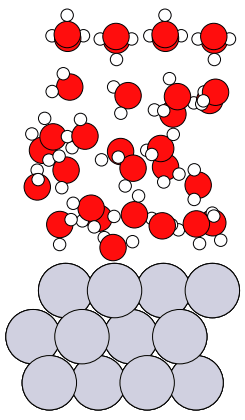

In [10]:
traj_path = 'Model.traj'
gif_name = 'md.gif'
rotation = '-90x,90y,0z'
duration = 5

trajectory = read(traj_path, index=':')
png_files = []

##-Write each frame as PNG
for i, frame in enumerate(trajectory):
  filename = f'frame_{i:04d}.png'
  write(filename, frame, show_unit_cell=0, rotation=rotation)
  png_files.append(filename)

##-Prepare images with white background for GIF
base_size = Image.open(png_files[0]).size
images = []

for filename in png_files:
  image = Image.open(filename).convert('RGBA')
  background = Image.new('RGBA', image.size, (255, 255, 255, 255))
  image = Image.alpha_composite(background, image).convert('RGB')
  images.append(image.resize(base_size))

##-Save GIF
imageio.mimsave(gif_name, images, duration=duration, loop=0)

##-Cleanup PNG files
for filename in png_files:
  os.remove(filename)

print(f'GIF saved as {gif_name}')
IPImage(gif_name)

## Summary

After completing this notebook, you should be able to:

1. Load and use a MACE foundation model.

2. Choose appropriate MD settings. Select a 0.5 fs timestep for systems containing O-H bonds to avoid integration instability from high-frequency vibrations, set a physically realistic temperature of 300 K rather than an artificially low one, and use a 500 fs Berendsen thermostat coupling time for gradual equilibration.
3. Convert a trajectory to an animated GIF. Use the trajectory_to_gif() function, which renders each frame as a PNG with ASE's write(), composites each frame onto a white background with Pillow to remove transparency, assembles the frames into a looping GIF with imageio, and cleans up intermediate files. Control the viewing angle with the rotation parameter and playback speed with duration.